# Visibility Timing Evaluator

This notebook evaluates the four visibility-timing conditions and produces only the six unified figures requested:

1. Rank, one aggregate line.
2. Rank, two sender-type lines: G sender vs. S sender.
3. Rank, four directional lines: GG, GS, SG, SS.
4. Diversity, one aggregate line.
5. Diversity, two sender-type lines: G sender vs. S sender.
6. Diversity, four directional lines: GG, GS, SG, SS.

All plotted values are averaged across K. Rank is inverted because a smaller rank indicates a better solution.

This evaluator is aligned with timing scripts that save files using the `visibility_start_{...}_interval_{...}` naming pattern.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {"weight": "bold"}

# =========================
# Configuration
# =========================
# Change this path to the folder that contains the saved pickle outputs.
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Timing_6")

agent_num = 200
visibility_start_list = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200]

# Must match visibility_interval in the running scripts.
# The updated scripts save files with `_interval_{visibility_interval}_` in the filename.
visibility_interval = 10

prefixes = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

# Only these two DVs are needed for the six requested figures.
dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "diversity": "Diversity",
}

# Black-and-white line styles for publication-friendly figures.
four_line_styles = {
    "gg": {"linestyle": "-",  "marker": "o", "label": "G → G"},
    "gs": {"linestyle": "--", "marker": "s", "label": "G → S"},
    "sg": {"linestyle": "-.", "marker": "^", "label": "S → G"},
    "ss": {"linestyle": ":",  "marker": "D", "label": "S → S"},
}

figure_size = (7.2, 5.0)


In [2]:
# =========================
# Load results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def result_file(prefix, visibility_start, dv, visibility_interval=visibility_interval):
    return result_folder / (
        f"{prefix}_visibility_start_{visibility_start}_"
        f"interval_{visibility_interval}_{dv}_across_K_size_{agent_num}"
    )


def load_visibility_timing_results(prefixes=prefixes, strict=True):
    """Load timing results into data[prefix][dv].

    Each data[prefix][dv] array has shape:
        visibility start × K, for the configured visibility_interval

    The plotting cells below average across K, so they are robust to whether
    the running scripts use K=[0,...,8] or K=[1,...,8], as long as each file
    has a consistent K dimension.
    """
    data = {}
    missing_files = []

    for prefix in prefixes:
        data[prefix] = {}
        for dv in dv_labels:
            rows = []
            for visibility_start in visibility_start_list:
                path = result_file(prefix, visibility_start, dv)
                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)
        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num is different from the saved file name.")
        print("4. visibility_interval does not match the saved file name.")
        print("5. File prefix is different, e.g., gg/gs/sg/ss.")

        if strict:
            raise FileNotFoundError("Some expected result files are missing.")

    return data


data = load_visibility_timing_results(strict=True)

print("Result folder:", result_folder)
print("Visibility interval:", visibility_interval)
print("Loaded data shapes:")
for prefix in prefixes:
    for dv in dv_labels:
        print(prefix, dv, data[prefix][dv].shape)


Result folder: /Volumes/T7/data/gst-0112-26/Timing_6
Visibility interval: 10
Loaded data shapes:
gg breakthrough_rank (10, 8)
gg diversity (10, 8)
gs breakthrough_rank (10, 8)
gs diversity (10, 8)
sg breakthrough_rank (10, 8)
sg diversity (10, 8)
ss breakthrough_rank (10, 8)
ss diversity (10, 8)


In [3]:
# =========================
# Plotting helpers
# =========================
def format_axis(ax, y_label, title, invert_y=False):
    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_linewidth(1.5)

    ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=12)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.grid(alpha=0.25)

    if invert_y:
        ax.invert_yaxis()


def save_and_show(fig, filename):
    output_path = result_folder / filename
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def mean_across_K(prefix, dv):
    return data[prefix][dv].mean(axis=1)


def overall_mean(dv):
    """Average across the four directional conditions and across K."""
    return np.mean([mean_across_K(prefix, dv) for prefix in prefixes], axis=0)


def sender_mean(sender, dv):
    """Average across receiver types and across K.

    G sender = average of GG and GS.
    S sender = average of SG and SS.
    """
    if sender == "G":
        selected = ["gg", "gs"]
    elif sender == "S":
        selected = ["sg", "ss"]
    else:
        raise ValueError("sender must be 'G' or 'S'")

    return np.mean([mean_across_K(prefix, dv) for prefix in selected], axis=0)


def plot_one_line(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=figure_size)
    ax.plot(
        visibility_start_list,
        overall_mean(dv),
        "-o",
        linewidth=2.5,
        markersize=7,
        color="black",
        markerfacecolor="white",
    )
    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    save_and_show(fig, filename)


def plot_sender_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=figure_size)
    ax.plot(
        visibility_start_list,
        sender_mean("G", dv),
        "-o",
        linewidth=2.5,
        markersize=7,
        color="black",
        markerfacecolor="white",
        label="G as sender",
    )
    ax.plot(
        visibility_start_list,
        sender_mean("S", dv),
        "-v",
        linewidth=2.5,
        markersize=7,
        color="black",
        markerfacecolor="white",
        label="S as sender",
    )
    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(frameon=False, prop=legend_properties)
    save_and_show(fig, filename)


def plot_four_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=figure_size)
    for prefix in prefixes:
        style = four_line_styles[prefix]
        ax.plot(
            visibility_start_list,
            mean_across_K(prefix, dv),
            linestyle=style["linestyle"],
            marker=style["marker"],
            linewidth=2.5,
            markersize=7,
            color="black",
            markerfacecolor="white",
            label=style["label"],
        )
    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(frameon=False, prop=legend_properties)
    save_and_show(fig, filename)


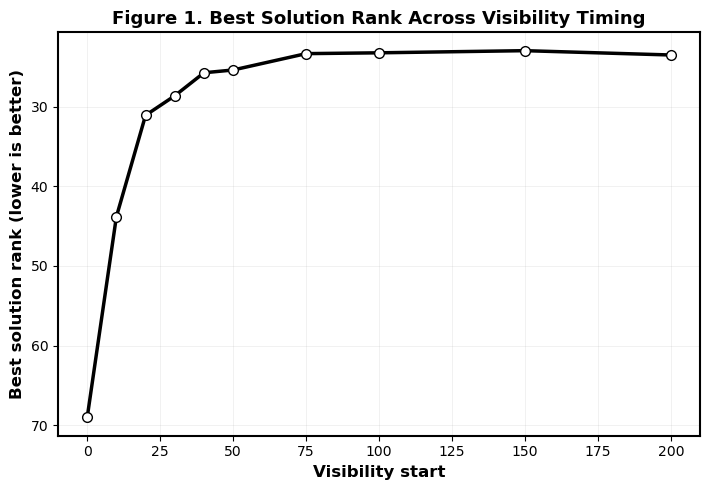

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_1_rank_one_line.png


In [4]:
# =========================
# Figure 1: One line — Rank across visibility timing
# =========================
plot_one_line(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 1. Best Solution Rank Across Visibility Timing",
    filename="figure_1_rank_one_line.png",
    invert_y=True,
)


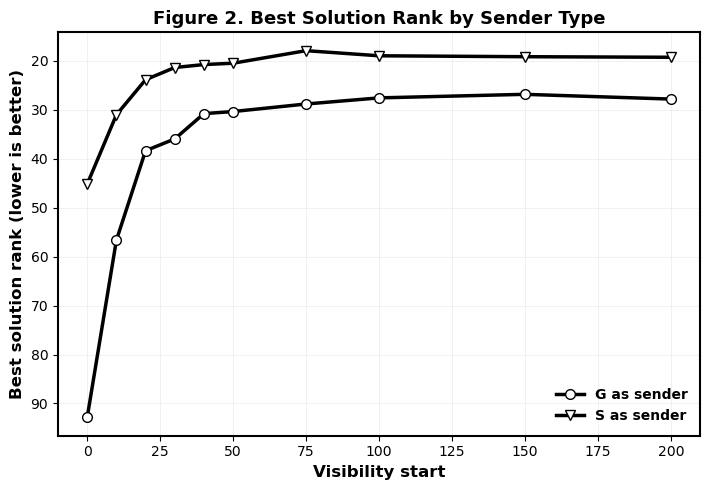

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_2_rank_sender_type.png


In [5]:
# =========================
# Figure 2: Two lines — Rank by sender type
# =========================
plot_sender_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 2. Best Solution Rank by Sender Type",
    filename="figure_2_rank_sender_type.png",
    invert_y=True,
)


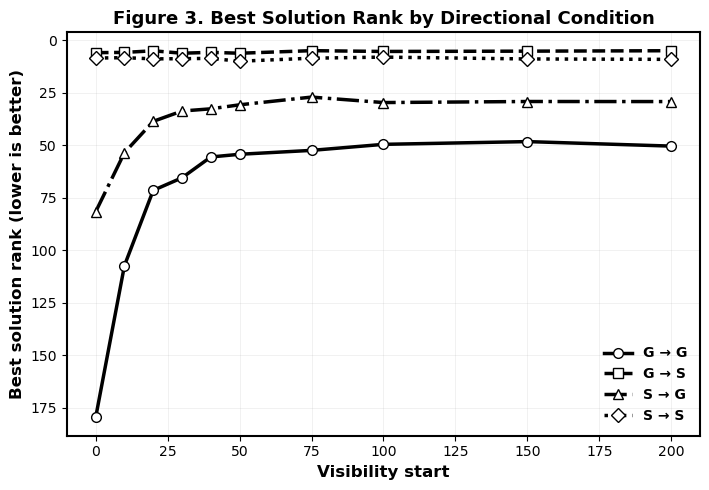

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_3_rank_four_conditions.png


In [6]:
# =========================
# Figure 3: Four lines — Rank by directional condition
# =========================
plot_four_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 3. Best Solution Rank by Directional Condition",
    filename="figure_3_rank_four_conditions.png",
    invert_y=True,
)


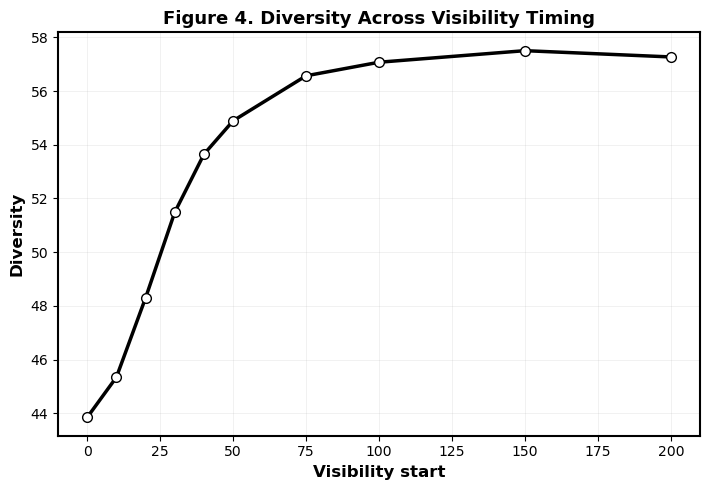

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_4_diversity_one_line.png


In [7]:
# =========================
# Figure 4: One line — Diversity across visibility timing
# =========================
plot_one_line(
    dv="diversity",
    y_label="Diversity",
    title="Figure 4. Diversity Across Visibility Timing",
    filename="figure_4_diversity_one_line.png",
    invert_y=False,
)


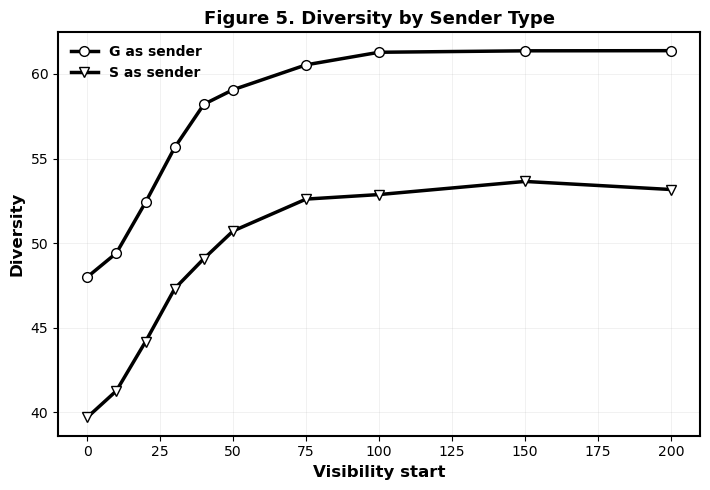

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_5_diversity_sender_type.png


In [8]:
# =========================
# Figure 5: Two lines — Diversity by sender type
# =========================
plot_sender_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 5. Diversity by Sender Type",
    filename="figure_5_diversity_sender_type.png",
    invert_y=False,
)


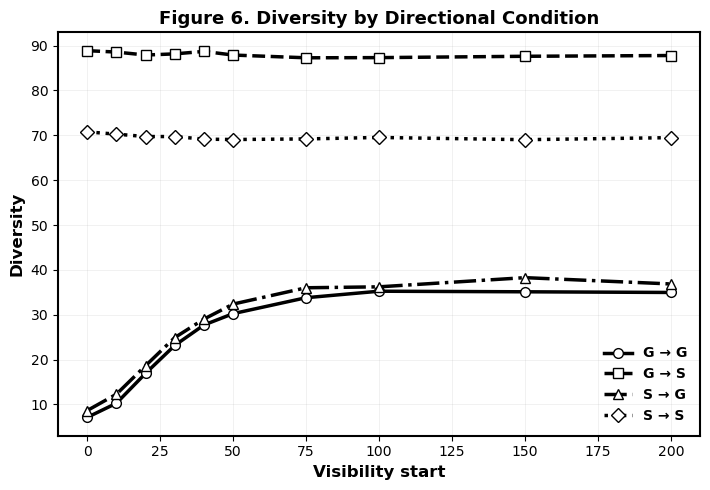

Saved: /Volumes/T7/data/gst-0112-26/Timing_6/figure_6_diversity_four_conditions.png


In [9]:
# =========================
# Figure 6: Four lines — Diversity by directional condition
# =========================
plot_four_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 6. Diversity by Directional Condition",
    filename="figure_6_diversity_four_conditions.png",
    invert_y=False,
)


In [10]:
# =========================
# Optional helper: inspect exact plotted values as tables
# =========================
def timing_table(dv="breakthrough_rank"):
    """Return the values used in the one-line, sender-type, and four-condition figures."""
    table = {
        "overall": overall_mean(dv).round(4).tolist(),
        "G_sender": sender_mean("G", dv).round(4).tolist(),
        "S_sender": sender_mean("S", dv).round(4).tolist(),
    }
    for prefix in prefixes:
        table[prefix] = mean_across_K(prefix, dv).round(4).tolist()

    columns = [f"timing={value}" for value in visibility_start_list]
    return table, columns


rank_table, columns = timing_table("breakthrough_rank")
diversity_table, _ = timing_table("diversity")

print("Columns:")
print(columns)
print("\nRank table:")
for key, values in rank_table.items():
    print(key, values)
print("\nDiversity table:")
for key, values in diversity_table.items():
    print(key, values)


Columns:
['timing=0', 'timing=10', 'timing=20', 'timing=30', 'timing=40', 'timing=50', 'timing=75', 'timing=100', 'timing=150', 'timing=200']

Rank table:
overall [69.0122, 43.8286, 31.0969, 28.6445, 25.7573, 25.4075, 23.3545, 23.2522, 22.9828, 23.5255]
G_sender [92.8519, 56.6397, 38.3512, 35.9412, 30.7697, 30.3466, 28.8041, 27.5541, 26.8272, 27.7978]
S_sender [45.1725, 31.0175, 23.8425, 21.3478, 20.745, 20.4684, 17.905, 18.9503, 19.1384, 19.2531]
gg [179.6888, 107.3888, 71.5806, 65.5988, 55.6881, 54.4019, 52.545, 49.6725, 48.3606, 50.5081]
gs [6.015, 5.8906, 5.1219, 6.2837, 5.8512, 6.2912, 5.0631, 5.4356, 5.2937, 5.0875]
sg [81.7612, 53.6394, 38.7206, 33.8081, 32.7569, 30.8456, 27.1675, 29.7681, 29.27, 29.3038]
ss [8.5838, 8.3956, 8.9644, 8.8875, 8.7331, 10.0912, 8.6425, 8.1325, 9.0069, 9.2025]

Diversity table:
overall [43.8461, 45.3409, 48.297, 51.4845, 53.6464, 54.8919, 56.5681, 57.0739, 57.5044, 57.2705]
G_sender [47.9912, 49.4112, 52.4134, 55.6562, 58.2072, 59.0659, 60.535, 61.27